### import Libs :

In [48]:
from langchain.document_loaders import CSVLoader
from langchain.embeddings import HuggingFaceEmbeddings
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

### Load Data and extract text :

In [15]:
# 1. Load CSV
loader = CSVLoader(
    file_path="../data/questions.csv",
    source_column="Question",
)

documents = loader.load()
print(documents)

# Extract text
texts = [doc.metadata['source'] for doc in documents]
print(texts)

[Document(metadata={'source': 'Does the PDF explain what is the largest ocean on earth?', 'row': 0}, page_content='Question: Does the PDF explain what is the largest ocean on earth?\nAnswer Status: Not Exist'), Document(metadata={'source': 'How many moons does Jupiter have?', 'row': 1}, page_content='Question: How many moons does Jupiter have?\nAnswer Status: Not Exist'), Document(metadata={'source': "Tell me what is the plot of the movie 'inception'?", 'row': 2}, page_content="Question: Tell me what is the plot of the movie 'inception'?\nAnswer Status: Not Exist"), Document(metadata={'source': 'How do you tie a tie?', 'row': 3}, page_content='Question: How do you tie a tie?\nAnswer Status: Not Exist'), Document(metadata={'source': 'Is there information about who is the lead singer of queen? in the document?', 'row': 4}, page_content='Question: Is there information about who is the lead singer of queen? in the document?\nAnswer Status: Not Exist'), Document(metadata={'source': 'Does th

### Select EMbedding Model :

In [16]:
# 2. Embeddings
model_name = "BAAI/bge-m3"
embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 775baeb1-7726-4701-a74e-32920a2b7312)')' thrown while requesting HEAD https://huggingface.co/BAAI/bge-m3/resolve/main/modules.json
Retrying in 1s [Retry 1/5].


In [17]:
# Embed texts
X = embeddings.embed_documents(texts)  

In [25]:
print(len(X[0]))
print(len(X))

1024
1000


### Get best k :

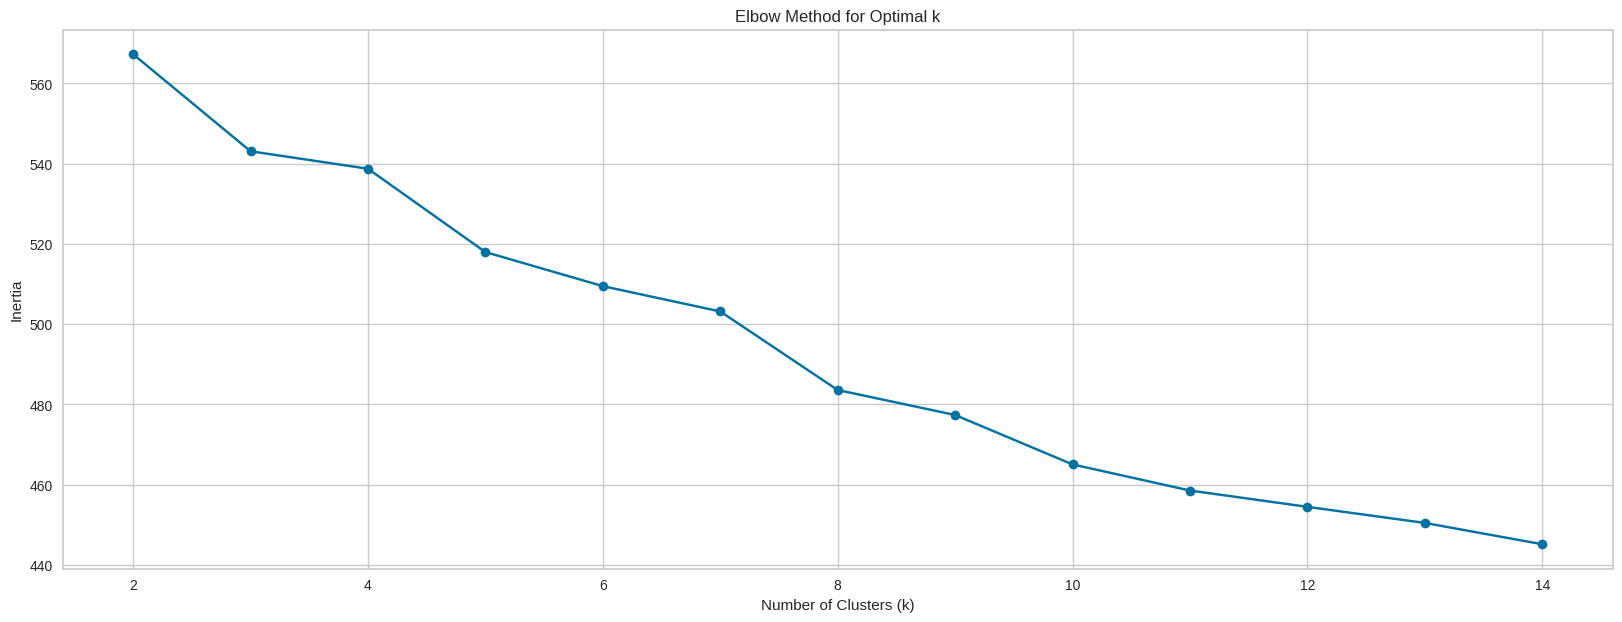

In [34]:
# 3. Elbow Method
inertia = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 4. Plot
plt.figure(figsize=(20, 7))
plt.plot(K_range, inertia, marker="o", scalex=10)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

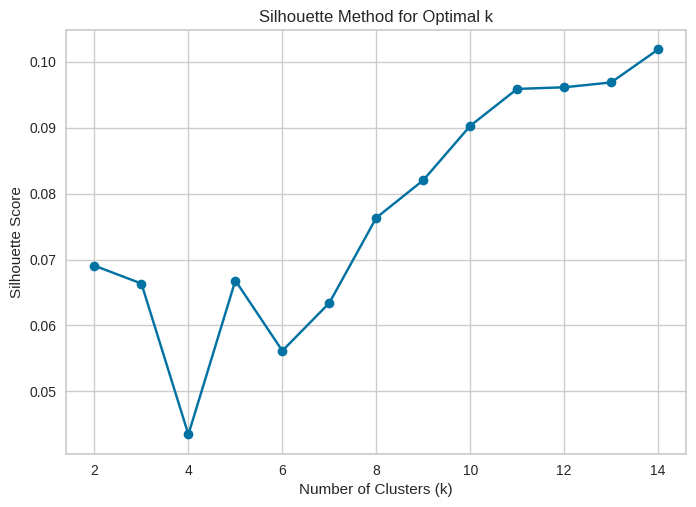

In [36]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.plot(K_range, sil_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

### Final Model ;

In [ ]:
from networkx import cluster
final_kmeans = KMeans(n_clusters=8, n_init="auto", random_state=42)
clusters = final_kmeans.fit_predict(X)



In [40]:
df = pd.read_csv('../data/questions.csv')
df['new_labels'] = clusters

### Save Model :

In [50]:
joblib.dump(final_kmeans, '../Models/kmeans_model.pkl')
print("Model saved with succes")

Model saved with succes


### test model :

In [51]:
loaded_kmeans = joblib.load('../Models/kmeans_model.pkl')
if loaded_kmeans :
    print("model loaded with succes")
else :
    print('Mode not Loaded')

model loaded with succes


In [52]:
Question = "What is it support ?"
Vector = embeddings.embed_query(Question)
print(Vector)

[-0.012716413475573063, -0.004595072939991951, -0.025737721472978592, 0.017727943137288094, 0.010777200572192669, -0.04911506921052933, 0.012830308638513088, 0.03556530177593231, 0.0327075757086277, -0.020883042365312576, -0.0483672171831131, -0.00792551040649414, -0.00805058516561985, -0.004970566835254431, -0.04106242209672928, -0.009758367203176022, 0.008660360239446163, 0.016255946829915047, 0.03028849884867668, -0.036167167127132416, -0.0732194036245346, 0.03346264734864235, -0.0032099559903144836, -0.02340683341026306, 0.0018153681885451078, 0.03275846317410469, 0.003139699809253216, 0.008621756918728352, 0.046940360218286514, -0.007916032336652279, 0.004233696032315493, -0.04027924686670303, 0.010804113000631332, -0.0019344356842339039, -0.0427125059068203, 0.023267051205039024, -0.0019329437054693699, -0.043116334825754166, -0.026132438331842422, -0.00864082109183073, -0.006059426348656416, -0.04710465669631958, 0.015718765556812286, 0.0022266535088419914, -0.015515039674937725

In [55]:
prediction = loaded_kmeans.predict([Vector])
print(f"Predection label is : {prediction[0]}")

Predection label is : 0


### Make name for each label : 

In [ ]:
for cluster_num in range(8):
    print(f"\n--- Cluster {cluster_num} ---")
    questions = df[df['new_labels'] == cluster_num]['Question'].head(10)
    for q in questions:
        print(f"- {q}") 


--- Cluster 0 ---
- I want to know what is the 'human factor' in it support?
- Can you tell me what is 'system information'?
- Can you tell me what is 'screencasting'?
- I want to know what is 'task manager'?
- Can you tell me what is 'performance monitor'?
- What is 'Quick Assist'?
- I want to know what is 'windows nt'?
- What is 'Understanding Your Users'?
- What is 'Windows vNext'?
- What is 'Windows vNext'?

--- Cluster 1 ---
- Is there information about who is the lead singer of queen? in the document?
- Is there information about what is the boiling point of gold? in the document?
- Is there information about what is the capital of kazakhstan? in the document?
- Is there information about who is the author of 'harry potter'? in the document?
- Is there information about how do you write a 'hello world' program in rust? in the document?
- Is there information about what is the weight of an adult elephant? in the document?
- Is there information about who wrote 'to kill a mockingb

In [62]:
cluster_map = {
    0: "Technical IT Support Concepts",
    1: "Document Fact-Checking",
    2: "Specific Book Terminology",
    3: "Book Structure & Chapters",
    4: "Out-of-Scope Queries",
    5: "Time-Sensitive/Current Events",
    6: "General Knowledge & Tutorials",
    7: "Author Personal Details"
}

df['new_labels_name'] = df['new_labels'].map(cluster_map)
df

,Question,Answer Status,new_labels,new_labels_name
0,Does the PDF explain what is the largest ocean...,Not Exist,4,Out-of-Scope Queries
1,How many moons does Jupiter have?,Not Exist,6,General Knowledge & Tutorials
2,Tell me what is the plot of the movie 'incepti...,Not Exist,6,General Knowledge & Tutorials
3,How do you tie a tie?,Not Exist,6,General Knowledge & Tutorials
4,Is there information about who is the lead sin...,Not Exist,1,Document Fact-Checking
...,...,...,...,...
995,What is the 'Xbox Game Bar' mentioned in Chapt...,Exist,3,Book Structure & Chapters
996,Does the PDF explain who is the ceo of tesla i...,Not Exist,5,Time-Sensitive/Current Events
997,Does the PDF explain what is the weight of an ...,Not Exist,4,Out-of-Scope Queries
998,Does the book mention what is 'screencasting'?,Exist,3,Book Structure & Chapters
